# Imports

In [2]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', 500)
pd.options.plotting.backend = "plotly"

# Data

In [3]:
filepath = os.path.join("..","data","processed","validations_fusion.csv")
df = pd.read_csv(filepath)

In [4]:
df.head()

,jour,libelle_arret,id_zdc,categorie_titre,nb_vald,nom_long,nom_so_gar,nom_su_gar,id_ref_zdc,nom_zdc,res_com,mode,train,rer,metro,tramway,val,tertrain,terrer,termetro,tertram,terval,exploitant,idf,principal,latitude,longitude
0,2025-03-07,MADELEINE,71324,Forfaits courts,3387,Madeleine,NaN,NaN,71324.0,Madeleine,METRO 8 / METRO 12 / METRO 14,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.870233,2.325164
1,2025-03-07,BARBES-ROCH.,71426,Autres titres,478,Barbès-Rochechouart,NaN,NaN,71426.0,Barbès Rochechouart,METRO 2 / METRO 4,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.883734,2.349525
2,2025-03-07,S. GAINSBOURG,490779,Contrat Solidarite Transport,781,Serge Gainsbourg,NaN,NaN,490779.0,Serge Gainsbourg,METRO 11,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.881316,2.427186
3,2025-03-07,S. GAINSBOURG,490779,Forfait Navigo,2880,Serge Gainsbourg,NaN,NaN,490779.0,Serge Gainsbourg,METRO 11,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.881316,2.427186
4,2025-03-07,S. GAINSBOURG,490779,Imagine R,1158,Serge Gainsbourg,NaN,NaN,490779.0,Serge Gainsbourg,METRO 11,METRO,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP,1.0,0.0,48.881316,2.427186


In [5]:
df.shape

(1890468, 27)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1890468 entries, 0 to 1890467
Data columns (total 27 columns):
 #   Column           Dtype  
---  ------           -----  
 0   jour             object 
 1   libelle_arret    object 
 2   id_zdc           int64  
 3   categorie_titre  object 
 4   nb_vald          int64  
 5   nom_long         object 
 6   nom_so_gar       object 
 7   nom_su_gar       object 
 8   id_ref_zdc       float64
 9   nom_zdc          object 
 10  res_com          object 
 11  mode             object 
 12  train            float64
 13  rer              float64
 14  metro            float64
 15  tramway          float64
 16  val              float64
 17  tertrain         float64
 18  terrer           float64
 19  termetro         float64
 20  tertram          float64
 21  terval           float64
 22  exploitant       object 
 23  idf              float64
 24  principal        float64
 25  latitude         float64
 26  longitude        float64
dtypes: float64(1

# Analyses.

## Validations par stations.

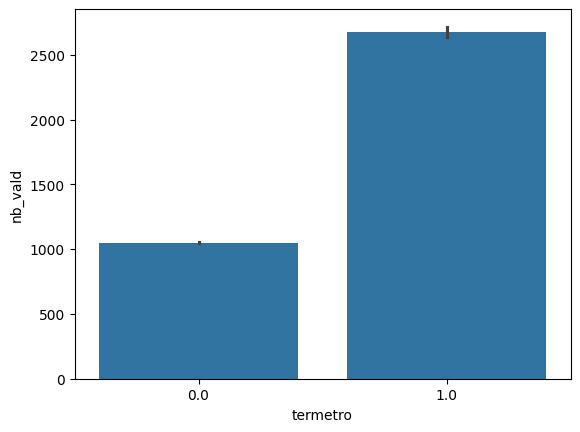

In [ ]:
# TEST: nombre ou somme ?

plt.figure()

sns.barplot(df, y="nb_vald", x="termetro")

plt.show()

In [17]:
#fig = px.scatter_map(
#    df,
#    lat="latitude",
#    lon="longitude",
#    hover_name= "nom_zdc",
#    hover_data="nb_vald"    
#)
#fig.update_layout(mapbox_style="open-street-map")
#fig.update_traces(marker_color='#64B5F6')
#fig

In [29]:
#fig = px.histogram(df, x="jour", y="nb_vald",)
#fig.update_traces(marker_color='#64B5F6')
#fig

In [ ]:
top_stations_df = df.sort_values(by="nb_vald", ascending=False).head()

In [ ]:
plt.figure()

sns.barplot(df, x="Ligne", y="somme_nb_vald", color="#64B5F6")

plt.show()

## Validations par lignes.

In [6]:
# Exemple filtrage des stations par lignes pour analyse.
df[df["res_com"].str.contains("RER B", na=False)].head()

,jour,libelle_arret,id_zdc,categorie_titre,nb_vald,nom_long,nom_so_gar,nom_su_gar,id_ref_zdc,nom_zdc,res_com,mode,train,rer,metro,tramway,val,tertrain,terrer,termetro,tertram,terval,exploitant,idf,principal,latitude,longitude
192,2025-03-07,SAINT-MICHEL,73620,Imagine R,4927,Saint-Michel,Notre-Dame,NaN,73620.0,Saint-Michel Notre-Dame,RER B / RER C / METRO 4,RER / METRO,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP/SNCF,1.0,0.0,48.853336,2.346035
261,2025-03-07,BOURGET T11,72641,Forfait Navigo,2488,Le Bourget,NaN,NaN,72641.0,Le Bourget,RER B / TRAM 11,RER / TRAM,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,SNCF,1.0,0.0,48.930740,2.425791
262,2025-03-07,BOURGET T11,72641,Forfaits courts,71,Le Bourget,NaN,NaN,72641.0,Le Bourget,RER B / TRAM 11,RER / TRAM,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,SNCF,1.0,0.0,48.930740,2.425791
347,2025-03-07,MASSY VERRIERES,63320,NON DEFINI,2,Massy-Verrières,NaN,NaN,63320.0,Massy - Verrières,RER B / RER C,RER,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP/SNCF,1.0,0.0,48.734888,2.274002
365,2025-03-07,SAINT-MICHEL NOTRE DAME,73620,Forfaits courts,4770,Saint-Michel,Notre-Dame,NaN,73620.0,Saint-Michel Notre-Dame,RER B / RER C / METRO 4,RER / METRO,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RATP/SNCF,1.0,0.0,48.853336,2.346035


In [7]:
# Somme "nb_vald" pour une ligne donnée.
df[df["res_com"].str.contains("RER B", na=False)]["nb_vald"].sum()

np.int64(190203361)

In [8]:
# List comprehension pour calculer le nombre de validations par lignes.

lignes = ['RER A', 'RER B', 'RER C', 'RER D', 'RER E', 'METRO 1', 'METRO 2', 'METRO 3', 'METRO 3bis','METRO 4', 'METRO 5', 'METRO 6', 'METRO 7', 'METRO 7bis','METRO 8', 'METRO 9', 'METRO 10', 'METRO 11', 'METRO 12', 'METRO 13', 'METRO 14', 'TRAIN H', 'TRAIN J', 'TRAIN K', 'TRAIN L', 'TRAIN N', 'TRAIN P', 'TRAIN R', 'TRAIN V', 'TRAM 1', 'TRAM 2', 'TRAM 3', 'TRAM 3a', 'TRAM 3b', 'TRAM 4', 'TRAM 5', 'TRAM 6', 'TRAM 7', 'TRAM 8', 'TRAM 9', 'TRAM 10', 'TRAM 11', 'TRAM 12', 'TRAM 13', 'TRAM 14', 'CABLE 1', 'CDGVAL', 'FUNICULAIRE MONTMARTRE']

lignes_df = pd.DataFrame({
    "Ligne": lignes,
    "somme_nb_vald": [df[df["res_com"].str.contains(l, na=False)]["nb_vald"].sum() for l in lignes]
})

lignes_df

,Ligne,somme_nb_vald
0,RER A,324994656
1,RER B,190203361
2,RER C,180974086
3,RER D,191192832
4,RER E,201652557
5,METRO 1,842868704
6,METRO 2,127083079
7,METRO 3,187142264
8,METRO 3bis,11019527
9,METRO 4,301538185


In [28]:
#fig = px.histogram(lignes_df, x="Ligne", y="somme_nb_vald",)
#fig.update_traces(marker_color='#64B5F6')
#fig

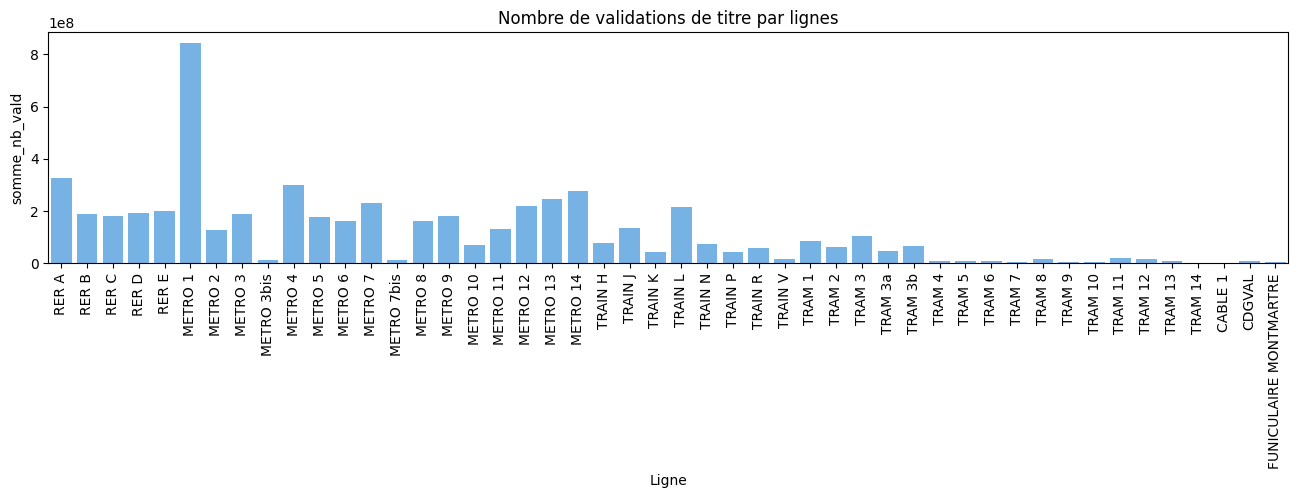

In [23]:
plt.figure(figsize=(16,3))

sns.barplot(lignes_df, x="Ligne", y="somme_nb_vald", color="#64B5F6")

plt.xticks(rotation="vertical")
plt.title("Nombre de validations de titre par lignes")

plt.show()

In [ ]:
# Top lignes.
top_lignes_df = lignes_df.sort_values(by="somme_nb_vald", ascending=False).head()
top_lignes_df

,Ligne,somme_nb_vald
5,METRO 1,842868704
0,RER A,324994656
9,METRO 4,301538185
20,METRO 14,278501830
19,METRO 13,245353261


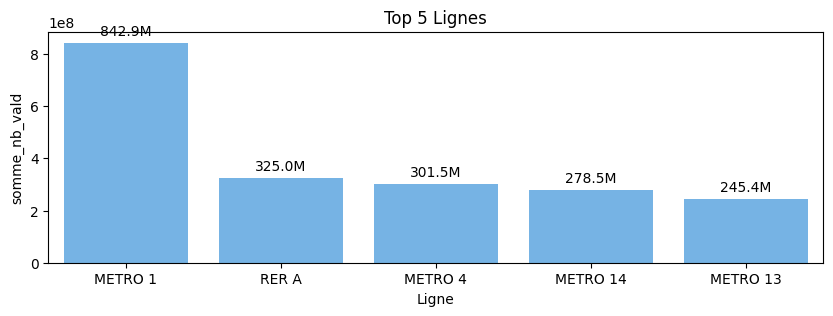

In [ ]:
# Top lignes graphique.

plt.figure(figsize=(10,3))

ax = sns.barplot(top_lignes_df, x="Ligne", y="somme_nb_vald", color="#64B5F6")

ax.bar_label(
    ax.containers[0],
    fmt=lambda x: f"{x*1e-6:.1f}M",
    padding=3
)

plt.title("Top 5 Lignes")
plt.xlabel("Nbre de validations")

plt.show()